In [2]:
import pandas as pd

df = pd.read_csv('../data/superstore.csv', sep=';')
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

df['sales'] = df['sales'].astype(str).str.replace(',', '.', regex=False).str.strip()
df['profit'] = df['profit'].astype(str).str.replace(',', '.', regex=False).str.strip()
df['discount'] = df['discount'].astype(str).str.replace(',', '.', regex=False).str.strip()
df['quantity'] = df['quantity'].astype(str).str.replace(',', '.', regex=False).str.strip()

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

df[['sales', 'profit', 'discount', 'quantity']].describe()

,sales,profit,discount,quantity
count,9.996000e+03,9995.000000,0.0,9994.000000
mean,4.596470e+02,57.308135,NaN,3.789574
std,2.298276e+04,2873.962192,NaN,2.225110
min,4.400000e-01,-6599.980000,NaN,1.000000
25%,1.728000e+01,1.730000,NaN,2.000000
50%,5.451500e+01,8.670000,NaN,3.000000
75%,2.099700e+02,29.360000,NaN,5.000000
max,2.297201e+06,286397.020000,NaN,14.000000


In [3]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
category_sales

category
Technology         836154.10
Furniture          741999.98
Office Supplies    719046.99
Name: sales, dtype: float64

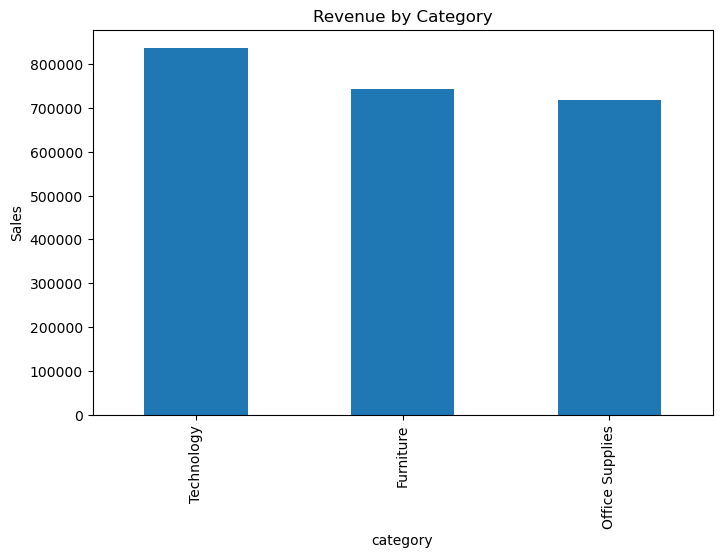

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Revenue by Category')
plt.ylabel('Sales')
plt.show()

In [5]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
category_profit

category
Technology         145455.66
Office Supplies    122490.88
Furniture           18451.25
Name: profit, dtype: float64

In [6]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales

region
West       725457.93
East       678781.36
Central    501239.88
South      391721.90
Name: sales, dtype: float64

In [12]:
df = df.dropna(subset=['order_date'])

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

df['month'] = df['order_date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales

month
2014-01     14236.90
2014-02      4519.92
2014-03     55691.04
2014-04     28295.35
2014-05     23648.28
2014-06     34595.14
2014-07     33946.37
2014-08     27909.47
2014-09     81777.34
2014-10     31453.37
2014-11     78628.74
2014-12     69545.64
2015-01     18174.08
2015-02     11951.40
2015-03     38726.26
2015-04     34195.25
2015-05     30131.72
2015-06     24797.31
2015-07     28765.32
2015-08     36898.32
2015-09     64595.87
2015-10     31404.90
2015-11     75972.51
2015-12     74919.52
2016-01     18542.52
2016-02     22978.82
2016-03     51715.86
2016-04     38750.04
2016-05     56987.75
2016-06     40344.54
2016-07     39261.99
2016-08     31115.35
2016-09     73410.09
2016-10     59687.80
2016-11     79412.03
2016-12     96999.07
2017-01     43971.37
2017-02     20301.12
2017-03     58872.35
2017-04     36521.52
2017-05     44261.08
2017-06     52981.73
2017-07     45264.43
2017-08     63120.85
2017-09     87866.66
2017-10     77776.96
2017-11    118447.81
2017-12

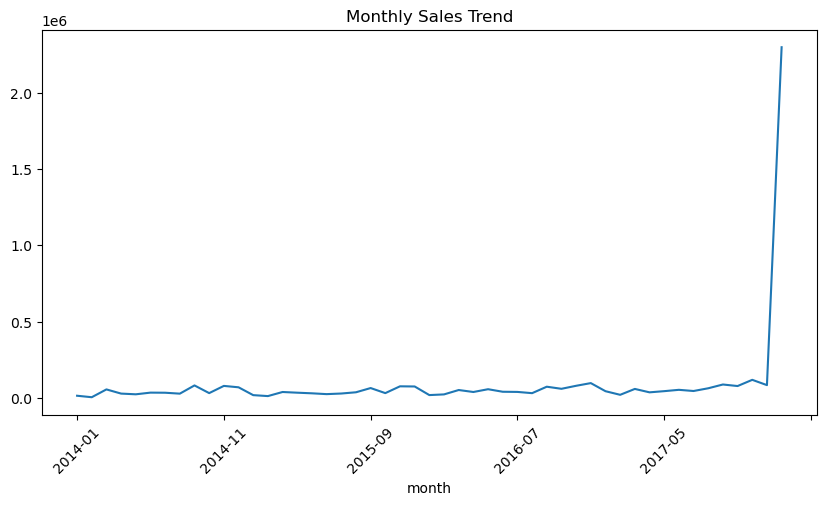

In [11]:
plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

In [14]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.83
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.57
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.68
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: sales, dtype: float64

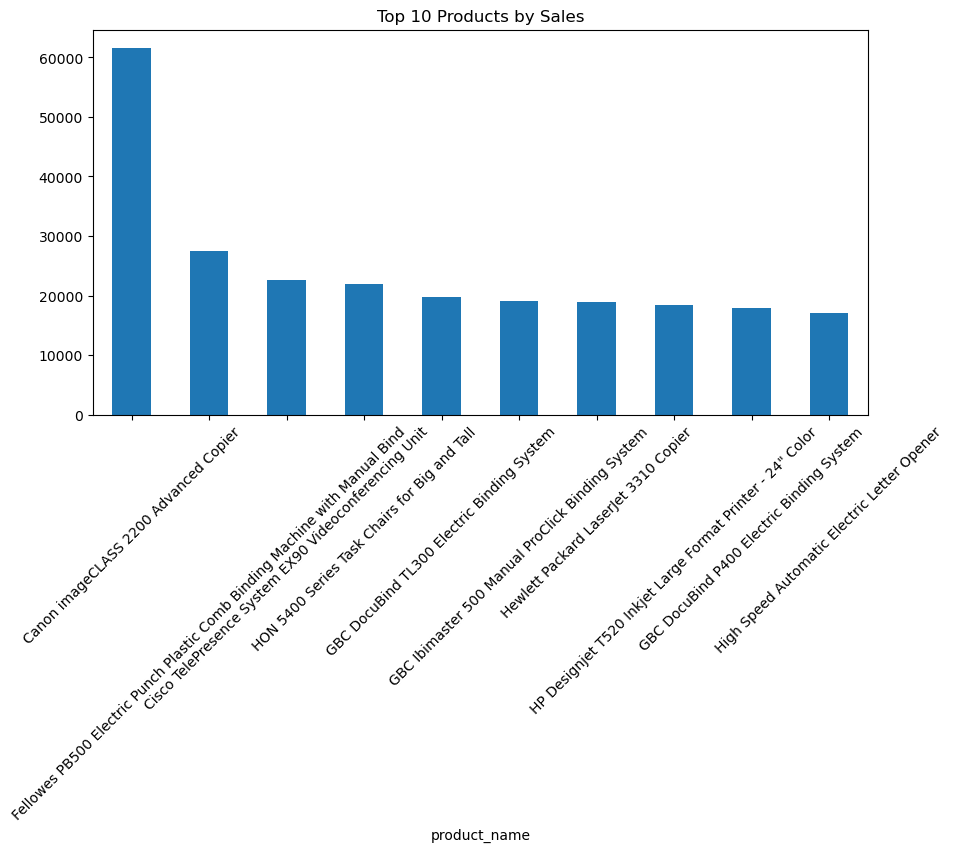

In [15]:
plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title('Top 10 Products by Sales')
plt.xticks(rotation=45)
plt.show()